In [31]:
# https://pandas.pydata.org/
import pandas

# https://matplotlib.org/
import matplotlib.pyplot as plt

# https://seaborn.pydata.org/
import seaborn as sns

# https://numpy.org/
import numpy as np

# Exploración

In [32]:
# https://vizier.cds.unistra.fr/viz-bin/VizieR-4
#file = "data_raw/vizier_I_239_hip_main_20260720.tsv"
file = "data_clean/vizier_I_239_hip_main_LimpiezaNaNPlx.tsv"

# leer .csv
df = pandas.read_csv(
    file,              # nombre y ruta del archivo
    sep = '\t',        # símbolo de separación de columnas
    nrows = 118218,    # número de filas que se leerán
    index_col = 'HIP', # nombre de la columna índice
)

# dataframe
print( type(df) )

df.head()

<class 'pandas.core.frame.DataFrame'>


,recno,Proxy,RAhms,DEdms,Vmag,VarFlag,r_Vmag,RAICRS,DEICRS,AstroRef,...,BD,CoD,CPD,(V-I)red,SpType,r_SpType,HIPep,Erratum,_RA.icrs,_DE.icrs
HIP,,,,,,,,,,,,,,,,,,,,,
1,1,NaN,00 00 00.22,+01 05 20.4,9.10,NaN,H,0.000912,1.089013,NaN,...,B+00 5077,NaN,NaN,0.66,F5,S,HIPep,Erratum,0.000899,1.089009
2,2,NaN,00 00 00.91,-19 29 55.8,9.27,NaN,G,0.003797,-19.498837,+,...,B-20 6688,NaN,NaN,1.04,K3V,4,HIPep,Erratum,0.004265,-19.498840
3,3,NaN,00 00 01.20,+38 51 33.4,6.61,NaN,G,0.005008,38.859286,NaN,...,B+38 5108,NaN,NaN,0.00,B9,S,HIPep,Erratum,0.005024,38.859279
4,4,NaN,00 00 02.01,-51 53 36.8,8.06,NaN,H,0.008382,-51.893546,NaN,...,NaN,NaN,P-52 12237,0.43,F0V,2,HIPep,Erratum,0.008629,-51.893546
5,5,NaN,00 00 02.39,-40 35 28.4,8.55,NaN,H,0.009965,-40.591224,NaN,...,NaN,C-41 15372,P-41 9991,0.95,G8III,2,HIPep,Erratum,0.009973,-40.591202



## Distancia en Astronomía

Calcular la distancia en astronomía es uno de los campos de investigación más activo. Esto es debido a la vasto del universo y las limitaciones técnicas con los telescopios. 

[Cosmic distance ladder](https://en.wikipedia.org/wiki/Cosmic_distance_ladder) en astronomía.

Se discute sobre uno de los métodos geométrico más viejo y simple para determinar distancias.

El concepto de paralaje surge de la idea de un movimiento aparente de las estrellas con respecto al fondo de galáctico cuando observamos desde algún lugar en la Tierra y con un lapso de observación de seis meses. Es decir, miramos una estrella y luego miramos la misma estrella cuando la Tierra está en el otro lado de su órbita. Este cambio de posición de la Tierra causa un desplazamiento en la posición de la estrella formando un arco en el cielo. Este desplazamiento angular de la estrella en el cielo es conocida como paralaje.

In [35]:
df['Plx']

HIP
1          3.54
2         21.90
3          2.81
4          7.75
5          2.87
          ...  
118318     1.92
118319    10.63
118320     5.00
118321    19.22
118322     8.71
Name: Plx, Length: 113710, dtype: float64

In [36]:
# valores únicos en paralaje
df['Plx'].unique()

array([ 3.54, 21.9 ,  2.81, ..., 57.62, 38.76, 34.47], shape=(4990,))

In [37]:
# cuáles son los cinco paralaje más comunes
# cuántas veces aparece en cada uno
# qué porcentaje del catálogo tiene cada brillo
df['Plx'].value_counts()

Plx
2.93     183
2.71     181
2.51     172
3.45     171
2.15     170
        ... 
38.20      1
68.32      1
46.90      1
48.53      1
34.47      1
Name: count, Length: 4990, dtype: int64

Calculamos la distancia del paralaje utilizando trigonometría. Algunos ejemplos se pueden encontrar [aquí](https://lco.global/spacebook/distance/parallax-and-distance-measurement/).

La distancia en pársec es dado por,

**distance = 1 / parallax**

el paralaje está medido en arco de segundos.

Nota: la medición de paralaje puede ser altamente imprecisa para distancias arriba de algunos kilopársecs (kpc).

Ahora se utiliza la relación distancia y paralaje para calcular las distancias de las estrellas en el catálogo de Hipparcos. El paralaje está medido en mili arco de segundos (mas). La unidad mas es cómun en el análisis del cielo. Debido a que la inversión directa del paralaje nos da la distancia en kpc, por lo que las distancias obtenidas se multiplica por un factor de 103 para obtener la distancia en pársecs.

Por simplicidad, se utilizara kilopársecs.

**1kpc = 103p**

In [38]:
distance = 1 / df['Plx']
distance

HIP
1         0.282486
2         0.045662
3         0.355872
4         0.129032
5         0.348432
            ...   
118318    0.520833
118319    0.094073
118320    0.200000
118321    0.052029
118322    0.114811
Name: Plx, Length: 113710, dtype: float64

Resumen estadístico de las distancias para tener un idea de qué tal lejos están las estrellas en el dataset.

In [39]:
distance.describe()

count    113710.000000
mean          0.453601
std           2.316921
min           0.001295
25%           0.115875
50%           0.208768
75%           0.367647
max         100.000000
Name: Plx, dtype: float64

In [40]:
# Taking care of the NaN values in parallaxes
hipp_df_par_corrected = df[ df["Plx"].notna() ] 

In [41]:
# Making sure parallaxes are positive and not too close to zero
hipp_df_par_corrected = hipp_df_par_corrected[ hipp_df_par_corrected.Plx > 0.1 ] 

In [42]:
# Add a new column name d with the parallaxes corrected
hipp_df_par_corrected["distance"] = 1 / hipp_df_par_corrected["Plx"]

hipp_df_par_corrected["distance"].describe()

count    113278.000000
mean          0.351714
std           0.596814
min           0.001295
25%           0.115473
50%           0.207900
75%           0.364964
max           9.090909
Name: distance, dtype: float64

Las distancias obtenidas parecen razonables para las distancias. La más cercas es de un pársec (0.001 kpc = 1 pársec), mientras que la más lejanas está a 10 kpc de distancia. Con la media de 200 pc.

La distribución no es normal, si no que está sesgada.
Visualicemos esta con la ayuda de un histograma.

### Distribución de distancia

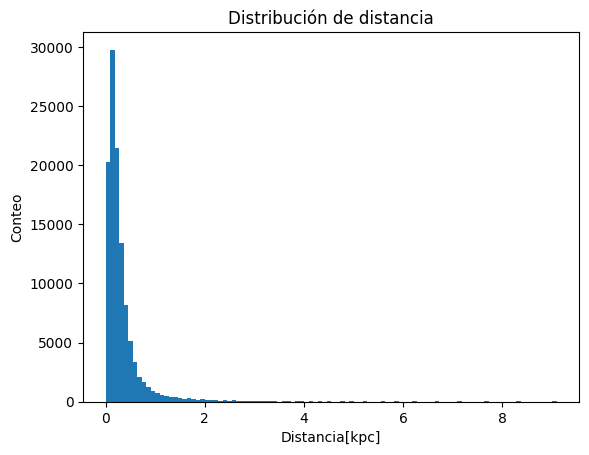

In [43]:
def distributionDistance():
    """
    """
    plt.hist(hipp_df_par_corrected["distance"], bins = 100)
    
    plt.title("Distribución de distancia")
    
    plt.xlabel("Distancia[kpc]")    
    plt.ylabel("Conteo")
    
    return plt.show()

# show
distributionDistance()

Una mejor manera de visualizar dichos datos es dibujar un KDE plot.

[Aquí](https://seaborn.pydata.org/generated/seaborn.kdeplot.html) hay una rápida guía para empezar con KDE plots.


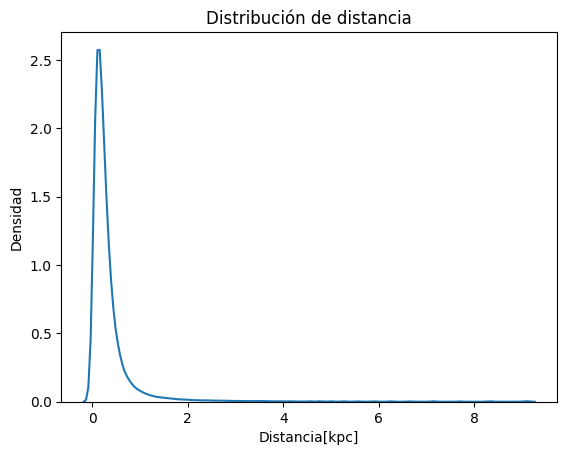

In [44]:
#
sns.kdeplot(data = hipp_df_par_corrected, x = "distance")

plt.title("Distribución de distancia")

plt.xlabel("Distancia[kpc]")
plt.ylabel("Densidad")

plt.show()


### Histograma de las distancias de Hipparcos

Primero, se reutilizará la función de limpieza para filtrar los datos y utilizar las distancias y magnitudes absolutas.

In [45]:
#
def graphPrepare2(dataframe):
    """ Prepare the data to graph the distance histogram
    """
    
    # remove bad entries and higher error
    valid_mask = (
        (dataframe['Plx'] > 0) &        
        (dataframe['e_Plx'] / dataframe['Plx'] < 0.2) &
        (dataframe['Plx'].notnull())  &
        
        (dataframe['e_VTmag'] < 0.1) &        
        (dataframe['VTmag'].notnull()) &           
        (dataframe['Vmag'].notnull()) 
    )

    # make a copy
    dataframe = dataframe[ valid_mask ].copy()

    # Distance (d) in parsecs, parallax is in milliseconds
    dataframe['distance_pc'] = 1000.0 / dataframe['Plx']

    # absolute magnitude calculation.  M = m - 5*log(d) + 5
    m = dataframe['VTmag']
    d = dataframe['distance_pc']
    dataframe['Mag'] = m - 5 * np.log10(d) + 5
    
    return dataframe

def plot_distance_histogram(dataframe, bin_width=100, max_distance=2000):
    """ Plot the distance histogram
    """

    # Generate synthetic star distance data (replace with actual DataFrame column in use)
    np.random.seed(42)
    synthetic_distances = np.random.exponential(scale=300, size=1000)  # Simulate clustered nearby stars

    # Filter for reasonable range
    max_distance = 2000
    bin_width = 100
    filtered_distances = synthetic_distances[synthetic_distances <= max_distance]
    bins = np.arange(0, max_distance + bin_width, bin_width)

    # Create histogram
    counts, bin_edges = np.histogram(filtered_distances, bins=bins)

    # Plot histogram with counts labeled
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.hist(filtered_distances, bins=bins, color='skyblue', edgecolor='black')

    # Annotate each bar with count
    for i in range(len(counts)):
        if counts[i] > 0:
            ax.text((bin_edges[i] + bin_edges[i+1]) / 2, counts[i] + 2, str(counts[i]),
                    ha='center', va='bottom', fontsize=8, rotation=0)

    ax.set_xlabel('Distancia (pc)')
    ax.set_ylabel('Número de estrellas')
    ax.set_title('Histograma de Distancia de las estrellas (con conteos)')
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()

    return plt.show()
    

Ahora hagamos un histograma agrupado con todas las estrellas.

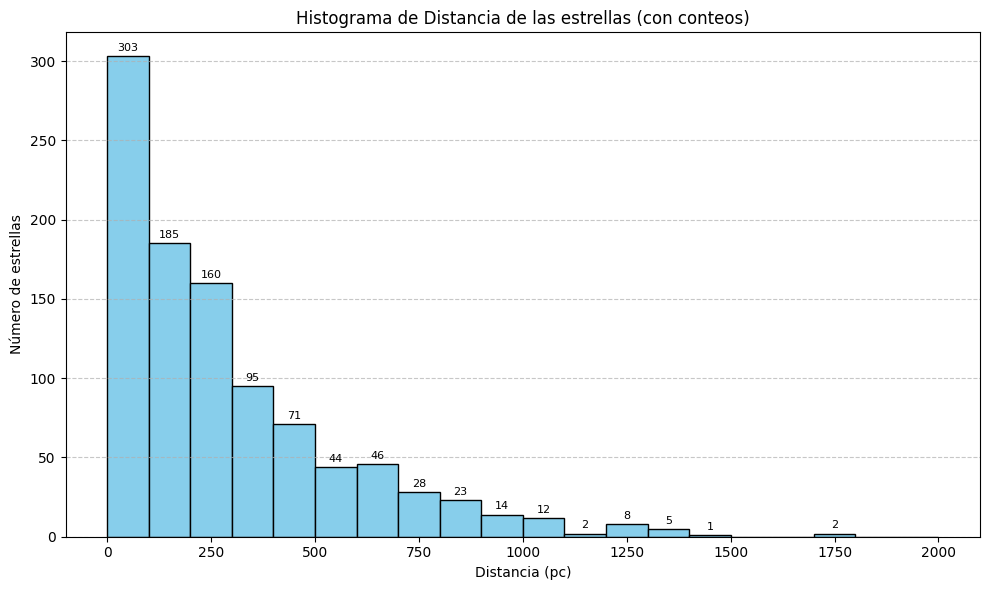

In [46]:
# listo dataframe
graph_df2 = graphPrepare2(df)    

plot_distance_histogram(graph_df2)

Vemos la relación inversa entre el conteo y las distancia, como Hipparcos pudo probarlo muy adentro en el espacio. Es esperado que la mayoría de las estrellas están muy lejos sean estrellas gigantes con altas luminosidades. Ahora analicemos la magnitud absoluta con la distancia.

## Sistema de magnitud en Astronomía

Ahora veamos los diferentes tipos de magnitudes usadas en Astronomía.

El primero de estos es la Vmag o la magnitud visual de las estrellas. Las estrellas en el cielo se designan con un número que nos dice qué tan fácil una estrella puede observada a simple vista en el cielo. Por razones históricas, la magnitud está definida de una manera que entre más bajo sea el valor de Vmag, mayor será el brillo de la estrella. Estas magnitudes son la magnitud aparente por el hecho de que estos valores de Vmag son observados por un telescopio. Hay una forma de convertir magnitudes aparentes en magnitudes absolutas.

In [47]:
df['Vmag']

HIP
1         9.10
2         9.27
3         6.61
4         8.06
5         8.55
          ... 
118318    6.99
118319    8.23
118320    7.59
118321    9.20
118322    4.49
Name: Vmag, Length: 113710, dtype: float64

In [48]:
# valores únicos en magnitud
df['Vmag'].unique()

array([ 9.1 ,  9.27,  6.61, ...,  2.44,  2.49, 13.11], shape=(1107,))

In [49]:
# cantidad total de valores únicos
df['Vmag'].nunique()

1107

In [50]:
df['Vmag'].value_counts

<bound method IndexOpsMixin.value_counts of HIP
1         9.10
2         9.27
3         6.61
4         8.06
5         8.55
          ... 
118318    6.99
118319    8.23
118320    7.59
118321    9.20
118322    4.49
Name: Vmag, Length: 113710, dtype: float64>

In [51]:
# cuáles son los cinco brillos más comunes
# cuántas veces aparece en cada uno
# qué porcentaje del catálogo tiene cada brillo
df['Vmag'].value_counts()

Vmag
8.27     489
8.69     485
8.60     483
8.52     479
8.40     475
        ... 
2.34       1
3.01       1
3.26       1
12.93      1
13.11      1
Name: count, Length: 1107, dtype: int64

In [52]:
hipp_df_par_corrected["Vmag"].describe()

count    113278.000000
mean          8.328954
std           1.295811
min          -1.440000
25%           7.610000
50%           8.410000
75%           9.100000
max          13.570000
Name: Vmag, dtype: float64

### Distribución de Vmag

Ahora, se observa la distribución de Vmag en un histograma.

Text(0.5, 1.0, 'Distribución de la magnitud visual aparente')

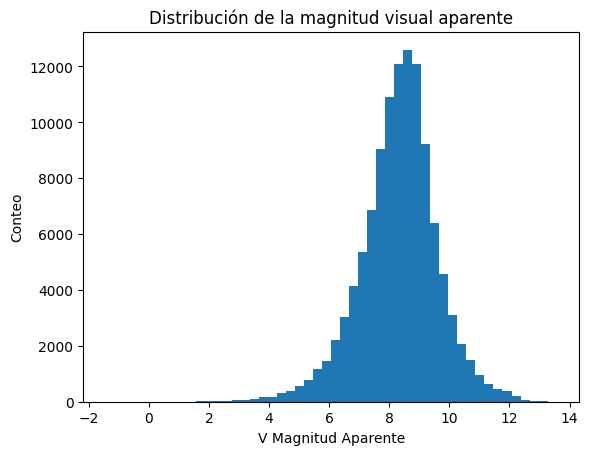

In [53]:
plt.hist(hipp_df_par_corrected["Vmag"], bins = 50)

plt.xlabel("V Magnitud Aparente")
plt.ylabel("Conteo")

plt.title("Distribución de la magnitud visual aparente")

Se observa que los picos de la distribución rondan el 8. El telescopio hizo un buen trabajo al buscar las estrellas que son difíciles de ver, debido a que las estrellas con Vmag mayor a 6 son las que no pueden ser vistas a simple vista. Esto es una prueba visual de cómo los telescopios cambiaron el campo de la Astronomía drasticamente desde el siglo XVII cuando con Galileo se introdujo el telescopio. El poder de cómputo y el desarrollo de la electrónica para el manejo de los telescopios son las razones por la que este campo revolucionó con la capacidad de captar estrellas más débiles.

El catálogo publicado más reciente por Gaia es Gaia DR3 (Data Release 3). Tiene estrellas con Vmag de ~21. Estas estrellas son débiles cuando se compara con las estrellas de Vmag del catálogo de Hipparcos.

Los otros sistemas de magnitud disponible en el catálogo de Hipparcos son los siguientes:

    BTmag: Mean BT magnitude
    VTmag: Mean VT magnitude
    Hpmag: The mean magnitude in the Hipparchos catalogue

Ahora revisemos la distribución de estos sistemas de magnitud en el catálogo.

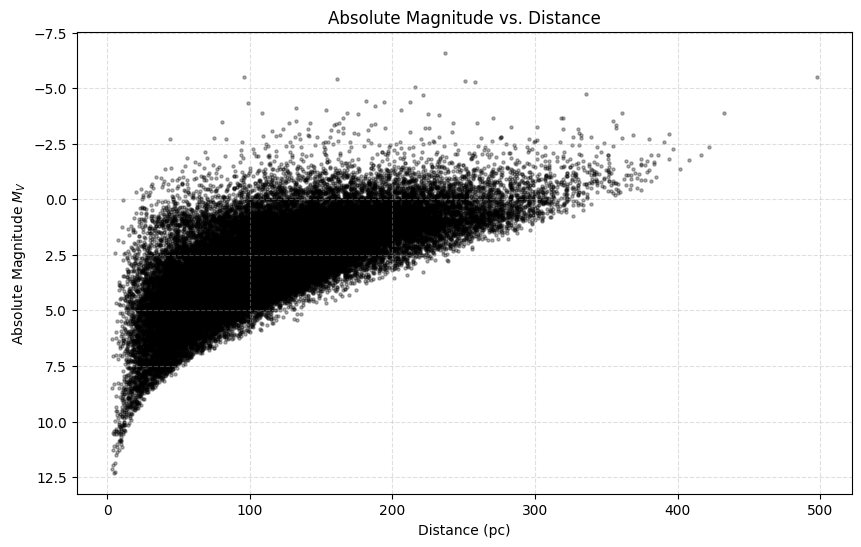

In [54]:
def plot_abs_mag_vs_distance(df):
    
    plt.figure(figsize=(10, 6))
    
    plt.scatter(df['distance_pc'], df['Mag'], s=5, alpha=0.3, color='black')
    
    plt.gca().invert_yaxis()

    plt.title('Absolute Magnitude vs. Distance')
    
    plt.xlabel('Distance (pc)')
    plt.ylabel('Absolute Magnitude $M_V$')
    
    plt.grid(True, which='both', linestyle='--', alpha=0.4)
    
    return plt.show()
    
plot_abs_mag_vs_distance(graph_df2)

Se observa el glorioso patrón logaritmico, que se espera de

m − M = 5 log(r) − 5

Magnitud absoluta varía al logaritmo de la distancia y los vemos en los datos.

## Luz - Vmag

In [55]:
# agrupando conteo de estrellas que tenga la magnitud y paralaje iguales
df[ ['Vmag', 'Plx'] ].value_counts()

Vmag   Plx 
8.33   2.73    5
8.61   3.05    5
9.02   3.11    5
8.53   3.15    5
8.69   3.26    5
              ..
7.89   3.84    1
       3.83    1
       3.79    1
       3.78    1
13.57  9.69    1
Name: count, Length: 101337, dtype: int64

In [56]:
# no hay estrellas en este catálogo con magnitud de 0.00 ni 0.01, pero sí -0.01
df.loc[ df['Vmag'] == -0.01 ]

,recno,Proxy,RAhms,DEdms,Vmag,VarFlag,r_Vmag,RAICRS,DEICRS,AstroRef,...,BD,CoD,CPD,(V-I)red,SpType,r_SpType,HIPep,Erratum,_RA.icrs,_DE.icrs
HIP,,,,,,,,,,,,,,,,,,,,,
71683,71619,NaN,14 39 40.90,-60 50 06.5,-0.01,NaN,G,219.92041,-60.835147,A,...,NaN,NaN,P-60 5483,0.69,G2V,X,HIPep,Erratum,219.902066,-60.833975


In [57]:
# cuatro estrellas están por debajo del 0 en magnitud
df.loc[ df['Vmag'] < 0 ]

,recno,Proxy,RAhms,DEdms,Vmag,VarFlag,r_Vmag,RAICRS,DEICRS,AstroRef,...,BD,CoD,CPD,(V-I)red,SpType,r_SpType,HIPep,Erratum,_RA.icrs,_DE.icrs
HIP,,,,,,,,,,,,,,,,,,,,,
30438,30417,NaN,06 23 57.09,-52 41 44.6,-0.62,2.0,H,95.987878,-52.695718,NaN,...,NaN,NaN,P-52 914,0.23,F0Ib,X,HIPep,Erratum,95.987958,-52.695660
32349,32325,NaN,06 45 09.25,-16 42 47.3,-1.44,2.0,G,101.288541,-16.713143,+,...,B-16 1591,NaN,NaN,-0.02,A0m...,4,HIPep,Erratum,101.287155,-16.716116
69673,69610,H,14 15 40.35,+19 11 14.2,-0.05,1.0,G,213.918114,19.187270,*,...,B+19 2777,NaN,NaN,1.22,K2IIIp,X,HIPep,Erratum,213.915300,19.182410
71683,71619,NaN,14 39 40.90,-60 50 06.5,-0.01,NaN,G,219.920410,-60.835147,A,...,NaN,NaN,P-60 5483,0.69,G2V,X,HIPep,Erratum,219.902066,-60.833975


In [58]:
# Entries with the 10 largest Vmag
df.nlargest(10, "Vmag")

,recno,Proxy,RAhms,DEdms,Vmag,VarFlag,r_Vmag,RAICRS,DEICRS,AstroRef,...,BD,CoD,CPD,(V-I)red,SpType,r_SpType,HIPep,Erratum,_RA.icrs,_DE.icrs
HIP,,,,,,,,,,,,,,,,,,,,,
58988,58941,NaN,12 05 38.69,-48 11 56.1,13.57,NaN,H,181.411224,-48.198928,B,...,NaN,NaN,NaN,0.76,NaN,NaN,HIPep,Erratum,181.411248,-48.198874
54738,54696,H,11 12 25.30,-76 44 21.5,13.50,NaN,H,168.105436,-76.739314,B,...,NaN,NaN,NaN,0.79,G8e...,K,HIPep,Erratum,168.105187,-76.739363
70185,70122,NaN,14 21 34.63,-16 15 30.5,13.45,NaN,H,215.394295,-16.258472,B,...,NaN,NaN,NaN,0.77,NaN,NaN,HIPep,Erratum,215.394036,-16.258501
86896,86821,NaN,17 45 19.59,-78 32 08.9,13.39,NaN,H,266.331616,-78.535815,B,...,NaN,NaN,NaN,0.77,NaN,NaN,HIPep,Erratum,266.331832,-78.535848
67593,67534,NaN,13 51 01.44,+23 45 49.1,13.31,NaN,H,207.756010,23.763626,B,...,NaN,NaN,NaN,0.72,NaN,NaN,HIPep,Erratum,207.762071,23.776677
26218,26200,NaN,05 35 14.20,-69 40 47.3,13.26,NaN,H,83.809157,-69.679802,B,...,NaN,NaN,NaN,0.74,NaN,NaN,HIPep,Erratum,83.809292,-69.679885
28699,28679,NaN,06 03 38.58,-31 35 25.0,13.25,NaN,H,90.910742,-31.590284,NaN,...,NaN,NaN,NaN,0.41,NaN,NaN,HIPep,Erratum,90.910745,-31.590245
115781,115679,NaN,23 27 23.49,-52 18 11.1,13.25,NaN,H,351.847878,-52.303097,B,...,NaN,NaN,NaN,0.72,NaN,NaN,HIPep,Erratum,351.847642,-52.303496
101453,101364,NaN,20 33 42.18,-05 38 49.2,13.22,3.0,H,308.425735,-5.647014,NaN,...,NaN,NaN,NaN,0.41,NaN,NaN,HIPep,Erratum,308.425782,-5.647008
